## 0. Project Overview: Система раннего обнаружения кризиса теплообмена

**Инженерная задача:**
В атомной и тепловой энергетике ключевой проблемой является предотвращение кризиса кипения — перехода от пузырькового кипения к пленочному, что ведет к резкому росту температуры стенки и аварии. Полные CFD-расчеты (вычислительная гидродинамика) точны, но крайне медленны (часы/дни), что делает их непригодными для оперативного анализа или многовариантной оптимизации.

**Роль Surrogate-модели:**
Мы разработали ML-модель, которая выступает в роли "суррогата" (заменителя) CFD. Она обучается на результатах прошлых CFD-расчетов и экспериментальных данных. Получив набор параметров сценария (геометрия, режим, показания датчиков), модель за миллисекунды предсказывает:
1.  Текущий режим кипения (0 - Норма, 1 - Пузырьковый, 2 - Предкризис, 3 - Кризис).
2.  Уверенность в своем прогнозе.
3.  Приоритет сценария для следующего, более детального CFD-расчета.

**Архитектура ML-системы:**
Многослойная архитектура, обеспечивающая надежность и промышленную применимость.

## 1. Dataset & Data Engineering

**Типы источников данных:**

| Источник | Описание |
|----------|----------|
| Experimental data | Исторические данные с испытательных стендов. Реальные измерения температуры, давления, расхода в различных режимах работы. |
| CFD simulation data | Результаты вычислительных экспериментов в пакетах ANSYS CFX, STAR-CCM+, ЛОГОС. Покрывают широкий диапазон режимных параметров. |
| Synthetic scenarios | Физически-обоснованная генерация данных для редких режимов (предкризис, кризис) на основе интерполяции между CFD расчетами. |

**Формат хранения:**
- csv
- Версионирование через DVC (Data Version Control)

In [42]:
# 1.1 Sources of data - Загрузка и структура датасета
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

import sys
import os
from pathlib import Path

# Добавляем корневую папку проекта в путь
project_root = Path.cwd().parent  # если ноутбук в notebooks/
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Настройка стиля для графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загружаем синтетический датасет
df = pd.read_csv("..\\data\\heat_exchange_synthetic_dataset.csv")

display(Markdown("### Структура датасета"))
print(f"Размер датасета: {df.shape[0]} сценариев, {df.shape[1]} признаков")

display(df.head())

display(Markdown("### Информация о колонках"))
# Группируем колонки по типу
static_cols = ['coolant_type', 'wall_material', 'hydraulic_diameter', 'channel_length']
regime_cols = ['inlet_temperature', 'pressure', 'mass_flux', 'heat_flux', 'flow_velocity']
signal_cols = ['wall_temp_mean', 'wall_temp_gradient', 'acoustic_rms',
               'peak_frequency', 'bubble_detachment_freq', 'vapor_area_ratio']
target_col = ['regime_label']

print(f"\nЦелевая переменная: {target_col[0]} (0-норма, 1-пузырьковое, 2-предкризис, 3-кризис)")

### Структура датасета

Размер датасета: 2000 сценариев, 16 признаков


,coolant_type,wall_material,hydraulic_diameter,channel_length,inlet_temperature,pressure,mass_flux,heat_flux,flow_velocity,wall_temp_mean,wall_temp_gradient,acoustic_rms,peak_frequency,bubble_detachment_freq,vapor_area_ratio,regime_label
0,lead_bismuth,zirconium,0.016777,1.229593,688.954172,14.685091,809.917555,657763.258319,1.926914,322.993094,129.138134,3.649992,3834.948172,137.105603,0.060570,0
1,helium,copper,0.016114,1.649778,403.431817,14.058377,732.532983,89232.244068,2.244828,320.224508,80.483699,0.922560,82.255763,93.514192,0.203208,0
2,water,inconel,0.045781,1.568290,823.436738,2.819330,434.692434,249906.513339,13.213487,641.139153,94.381822,1.733198,2411.397192,11.141379,0.491263,1
3,lead_bismuth,copper,0.016230,0.477020,667.869743,18.528876,1253.806673,775942.553014,9.995344,339.919719,143.344957,3.316403,3979.826781,183.702030,0.368150,2
4,lead_bismuth,copper,0.017238,0.468649,394.322330,11.800972,1005.585905,533398.995142,15.913097,982.682136,175.261206,2.410447,3168.721367,196.065827,0.410912,1


### Информация о колонках


Целевая переменная: regime_label (0-норма, 1-пузырьковое, 2-предкризис, 3-кризис)


### Pairplot ключевых признаков с целевой переменной

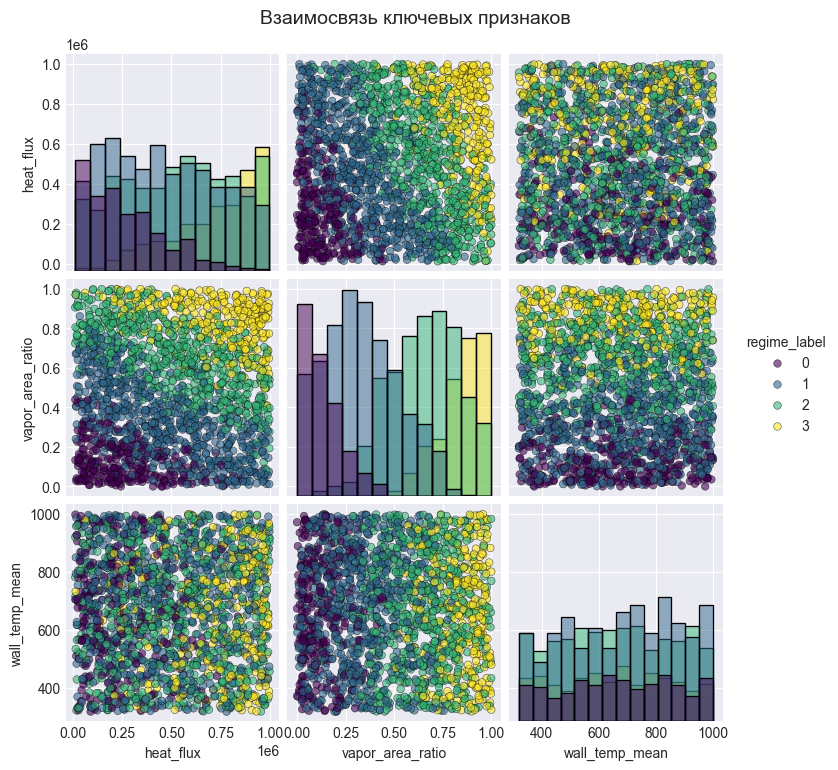

In [43]:
# 1.2 Feature groups - Визуализация распределений
import warnings
warnings.filterwarnings('ignore')

display(Markdown("### Pairplot ключевых признаков с целевой переменной"))
# Выбираем репрезентативные признаки из каждой группы
pairplot_features = ['heat_flux', 'vapor_area_ratio', 'wall_temp_mean', 'regime_label']

# Создаем pairplot с окраской по режимам
g = sns.pairplot(df[pairplot_features],
                 hue='regime_label',
                 palette='viridis',
                 diag_kind='hist',
                 plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'})
g.fig.suptitle('Взаимосвязь ключевых признаков', y=1.02, fontsize=14)
plt.show()

### Анализ целевой переменной

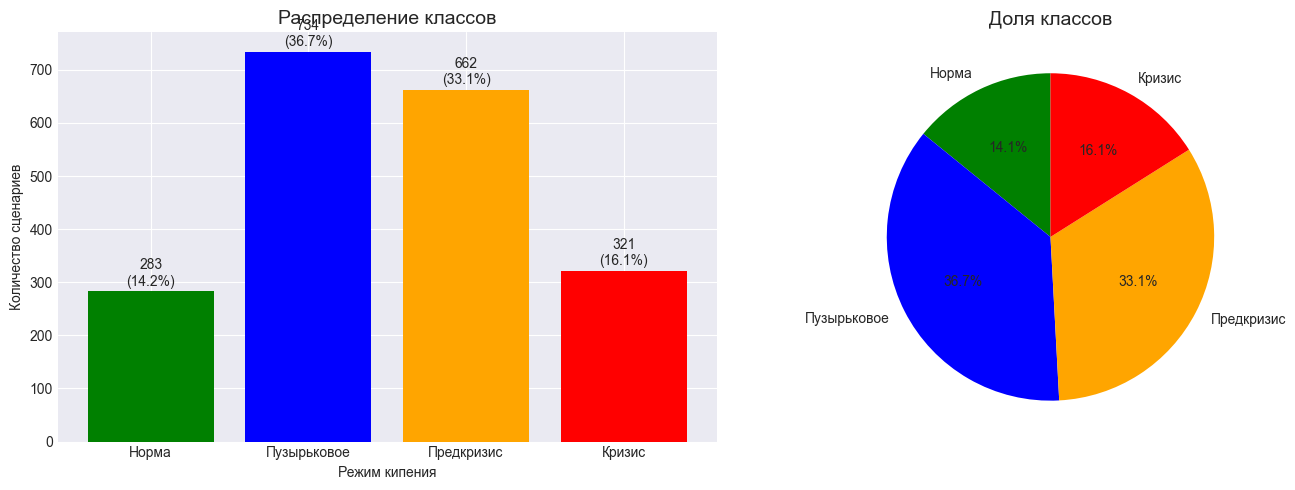


Дисбаланс классов: классы 2 (предкризис) и 3 (кризис) составляют всего 49.1% данных
→ Будем использовать F2-метрику и class weights для компенсации


In [37]:
# 1.3 Анализ целевой переменной (дисбаланс классов)
display(Markdown("### Анализ целевой переменной"))

# Распределение классов
class_counts = df['regime_label'].value_counts().sort_index()
class_names = {0: 'Норма', 1: 'Пузырьковое', 2: 'Предкризис', 3: 'Кризис'}
class_labels = [class_names[i] for i in class_counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Барплот
bars = ax1.bar(class_labels, class_counts.values, color=['green', 'blue', 'orange', 'red'])
ax1.set_title('Распределение классов', fontsize=14)
ax1.set_xlabel('Режим кипения')
ax1.set_ylabel('Количество сценариев')

# Добавляем проценты на столбцы
total = len(df)
for bar, count in zip(bars, class_counts.values):
    percentage = 100 * count / total
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({percentage:.1f}%)', ha='center', va='bottom')

# Пайчарт
colors = ['green', 'blue', 'orange', 'red']
wedges, texts, autotexts = ax2.pie(class_counts.values,
                                    labels=class_labels,
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90)
ax2.set_title('Доля классов', fontsize=14)

plt.tight_layout()
plt.show()

print(f"\nДисбаланс классов: классы 2 (предкризис) и 3 (кризис) составляют всего {100 * (class_counts[2] + class_counts[3])/total:.1f}% данных")
print("→ Будем использовать F2-метрику и class weights для компенсации")

## 2. Feature Engineering Layer

### 2.1 Anomaly Detection - определение аномалий

Всего сценариев: 2000
Нормальные сценарии: 1900 (95.0%)
Аномалии (выбросы): 100 (5.0%)


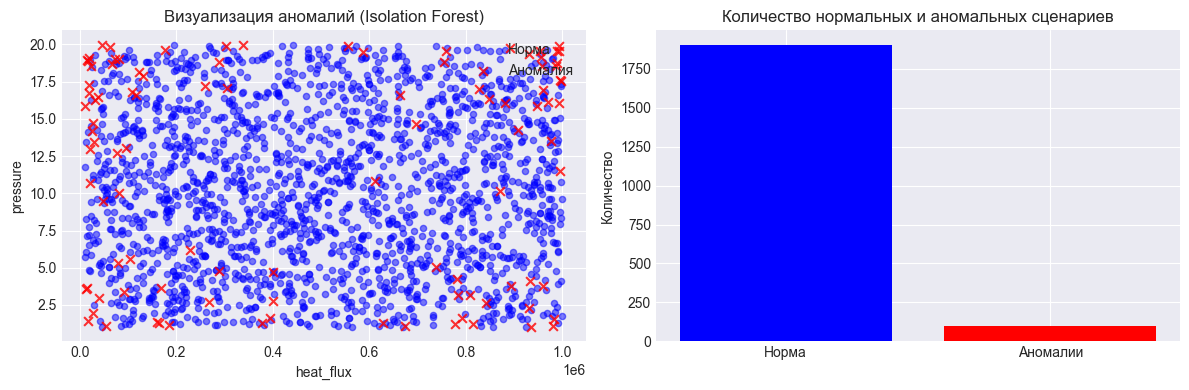

### 2.2 Data Split (Group-aware + anomaly filtering)

  • Нормальных сценариев: 1900
  • Аномалий (исключены из train): 100
  • Аномалии не включены в train (используются только для валидации)


### 2.3 Feature Engineering

Создание инженерных признаков на train...
Добавлено 14 новых признаков:
  • temp_gradient
  • delta_t_wall_coolant
  • h_approx
  • thermal_inertia
  • Re_proxy
  • flow_resistance_proxy
  • time_to_fluence
  • norm_acoustic

Пример (первые 3 строки с новыми признаками):


,heat_flux,temp_gradient,time_to_fluence,margin_to_critical
0,657763.258319,-365.961078,657763.258319,0.866769
5,928689.371169,-406.398516,928689.371169,0.740746
7,871114.242156,17.834517,871114.242156,0.725891


### 2.4 Preprocessing Pipeline

Обучение preprocessing pipeline на train...


In [45]:
from src.data_validation.anomaly_detector import AnomalyDetector
from src.data.data_splitter import DataSplitter
from src.pipelines.feature_pipeline import FeaturePipeline
from src.data.feature_engineering import create_features, get_feature_groups

display(Markdown("## 2. Feature Engineering Layer"))

# ============================================================================
# ШАГ 1: Anomaly Detection (определяем, какие сценарии аномальны)
# ============================================================================
display(Markdown("### 2.1 Anomaly Detection - определение аномалий"))

# Выбираем признаки для детекции аномалий
numeric_features = ['heat_flux', 'pressure', 'mass_flux', 'wall_temp_mean', 'acoustic_rms']
X_numeric = df[numeric_features].values

# Обучаем детектор аномалий на ВСЕХ данных (чтобы определить выбросы)
anomaly_detector = AnomalyDetector(contamination=0.05)
anomaly_detector.fit(X_numeric)

# Получаем предсказания (1 - норма, -1 - аномалия)
anomaly_predictions = anomaly_detector.predict(X_numeric)
anomaly_mask = anomaly_predictions == -1

print(f"Всего сценариев: {len(df)}")
print(f"Нормальные сценарии: {(~anomaly_mask).sum()} ({(~anomaly_mask).sum()/len(df)*100:.1f}%)")
print(f"Аномалии (выбросы): {anomaly_mask.sum()} ({anomaly_mask.sum()/len(df)*100:.1f}%)")

# Визуализация аномалий
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 2D проекция
normal_data = X_numeric[~anomaly_mask]
anomaly_data = X_numeric[anomaly_mask]

axes[0].scatter(normal_data[:, 0], normal_data[:, 1],
                alpha=0.5, s=20, c='blue', label='Норма')
axes[0].scatter(anomaly_data[:, 0], anomaly_data[:, 1],
                alpha=0.8, s=40, c='red', marker='x', label='Аномалия')
axes[0].set_xlabel(numeric_features[0])
axes[0].set_ylabel(numeric_features[1])
axes[0].set_title('Визуализация аномалий (Isolation Forest)')
axes[0].legend()

# Распределение
axes[1].bar(['Норма', 'Аномалии'],
            [(~anomaly_mask).sum(), anomaly_mask.sum()],
            color=['blue', 'red'])
axes[1].set_title('Количество нормальных и аномальных сценариев')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

# ============================================================================
# ШАГ 2: Разделение данных (с учетом аномалий)
# ============================================================================
display(Markdown("### 2.2 Data Split (Group-aware + anomaly filtering)"))

# Инициализируем сплиттер
splitter = DataSplitter(
    test_size=0.2,
    val_size=0.2,
    random_state=42,
    group_col='wall_material'
)

# Разделяем данные, передавая маску аномалий
# Аномалии НЕ попадают в train, но могут быть в val/test
train_df, val_df, test_df = splitter.split(
    df,
    target_col='regime_label',
    anomaly_mask=anomaly_mask
)

# ============================================================================
# ШАГ 3: Feature Engineering (только на train, потом применяем к val/test)
# ============================================================================
display(Markdown("### 2.3 Feature Engineering"))

# Создаем инженерные признаки на тренировочных данных
print("Создание инженерных признаков на train...")
train_with_features = create_features(train_df)

new_features = [col for col in train_with_features.columns if col not in train_df.columns]
print(f"Добавлено {len(new_features)} новых признаков:")
for feat in new_features[:8]:
    print(f"  • {feat}")

# Показываем пример
print("\nПример (первые 3 строки с новыми признаками):")
display(train_with_features[['heat_flux', 'temp_gradient', 'time_to_fluence', 'margin_to_critical']].head(3))

# ============================================================================
# ШАГ 4: Preprocessing (imputing, scaling, encoding) - FIT НА TRAIN
# ============================================================================
display(Markdown("### 2.4 Preprocessing Pipeline"))

# Инициализируем FeaturePipeline (который включает preprocessor)
feature_pipeline = FeaturePipeline()

# FIT только на train!
print("Обучение preprocessing pipeline на train...")
X_train_processed = feature_pipeline.fit_transform(
    train_df,
    target_col='regime_label',
    categorical_cols=['coolant_type', 'wall_material']
)

X_val_processed = feature_pipeline.transform(val_df)
X_test_processed = feature_pipeline.transform(test_df)

# Получаем названия признаков после обработки
feature_names = feature_pipeline.get_feature_names()

# Отделяем целевую переменную
y_train = train_df['regime_label'].values
y_val = val_df['regime_label'].values
y_test = test_df['regime_label'].values


Project root: d:\gmi\heat_exchange_crisis_ml
Python path: ['C:\\Program Files\\Python313\\python313.zip', 'C:\\Program Files\\Python313\\DLLs', 'C:\\Program Files\\Python313\\Lib', 'C:\\Program Files\\Python313', 'd:\\gmi\\.venv', '', 'd:\\gmi\\.venv\\Lib\\site-packages', 'd:\\gmi\\heat_exchange_crisis_ml']


# 3. Model Training


Train Pipeline включает:
1. Anomaly Detection (исключение выбросов из train)
2. Group-aware split (по материалу стенки)
3. Feature Engineering (физические признаки)
4. Preprocessing (imputing, scaling, encoding)
5. Обучение стекинг модели (CatBoost + XGBoost)
6. Оценка на валидации и тесте
7. Сохранение модели и метаданных

ЗАПУСК TRAIN PIPELINE

[1] Загрузка данных...
    Загружено 2000 сценариев

[2] Anomaly Detection...
    Аномалий: 100 (5.0%)

[3] Разделение данных...
  • Нормальных сценариев: 1900
  • Аномалий (исключены из train): 100
  • Аномалии не включены в train (используются только для валидации)
    Train: 930
    Val: 485
    Test: 485

[4] Feature Engineering...
    Признаков после обработки: 33

[5] Обучение модели...

[6] Оценка модели...
    F2-val: 0.7232
    F2-test: 0.7421

[7] Сохранение модели...
✓ Модель сохранена: models\boiling_model_20260312_193745.pkl
    Модель сохранена: models\boiling_model_20260312_193745.pkl

TRAIN PIPELINE ЗАВЕРШЕН

Модель сохранена:

## Результаты обучения

,Метрика,Значение
0,F2-score (val),0.7232
1,F2-score (test),0.7421
2,Recall (val),0.7192
3,Recall (test),0.7356


## ROC-кривые

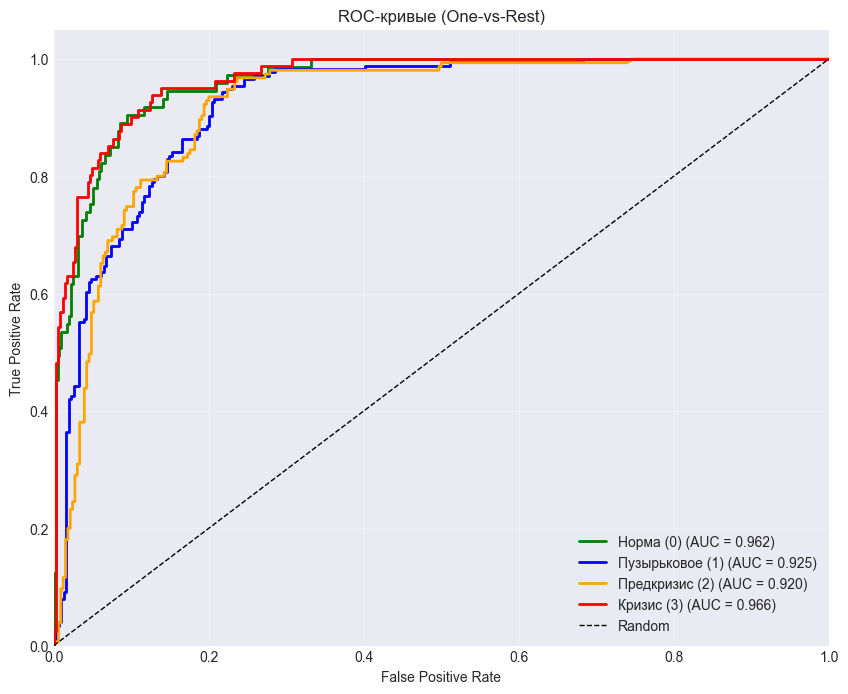

In [51]:
import sys
import os
from pathlib import Path

# Добавляем корневую папку проекта в путь
project_root = Path.cwd().parent  # если ноутбук в notebooks/
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Project root: {project_root}")
print(f"Python path: {sys.path}")

# ============================================================================
# Глава 3. Model Training
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import json
import glob

from src.pipelines.train_pipeline import TrainPipeline
from src.models.train_model import build_model, evaluate_model
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.dummy import DummyClassifier
from sklearn.metrics import fbeta_score, recall_score, precision_score

display(Markdown("# 3. Model Training"))

print("""
Train Pipeline включает:
1. Anomaly Detection (исключение выбросов из train)
2. Group-aware split (по материалу стенки)
3. Feature Engineering (физические признаки)
4. Preprocessing (imputing, scaling, encoding)
5. Обучение стекинг модели (CatBoost + XGBoost)
6. Оценка на валидации и тесте
7. Сохранение модели и метаданных
""")

# Инициализируем пайплайн
pipeline = TrainPipeline(random_state=42)

results = pipeline.run(
    data_path='D:\gmi\heat_exchange_crisis_ml\data\heat_exchange_synthetic_dataset.csv',
    target_col='regime_label',
    test_size=0.2,
    val_size=0.2,
    contamination=0.05,
    save_model=True
)

# Извлекаем результаты
model = results['model']
metrics = results['metrics']
feature_pipeline = results['feature_pipeline']
anomaly_detector = results['anomaly_detector']

# Находим путь к сохраненной модели
model_files = sorted(glob.glob("models/boiling_model_*.pkl"))
if model_files:
    model_path = model_files[-1]
    print(f"\nМодель сохранена: {model_path}")
else:
    model_path = None
    print("\nМодель не найдена в папке models/")


display(Markdown("## Результаты обучения"))

# Метрики из пайплайна
metrics_df = pd.DataFrame({
    'Метрика': ['F2-score (val)', 'F2-score (test)', 'Recall (val)', 'Recall (test)'],
    'Значение': [
        f"{metrics['f2_val']:.4f}",
        f"{metrics['f2_test']:.4f}",
        f"{metrics['recall_val']:.4f}",
        f"{metrics['recall_test']:.4f}"
    ]
})
display(metrics_df)

X_test = feature_pipeline.transform(test_df)
y_test = test_df['regime_label'].values
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)

display(Markdown("## ROC-кривые"))

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = 4

plt.figure(figsize=(10, 8))
colors = ['green', 'blue', 'orange', 'red']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Project root: d:\gmi\heat_exchange_crisis_ml


# 5. Applicability Domain


Зачем нужен Applicability Domain?

Модель машинного обучения работает хорошо только на данных, похожих на обучающие.
Applicability Domain определяет границы, за пределами которых модель может давать
ненадежные предсказания.

Основная идея:

1. Вычисляем расстояние от нового сценария до обучающих данных
2. Если расстояние большое - сценарий "незнакомый" модели
3. Отправляем такие сценарии на полный CFD расчет



Mahalanobis distance


Mahalanobis distance учитывает корреляцию между признаками:

D² = (x - μ)ᵀ · Σ⁻¹ · (x - μ)

где:
- μ - среднее обучающих данных
- Σ - ковариационная матрица



## Визуализация границ

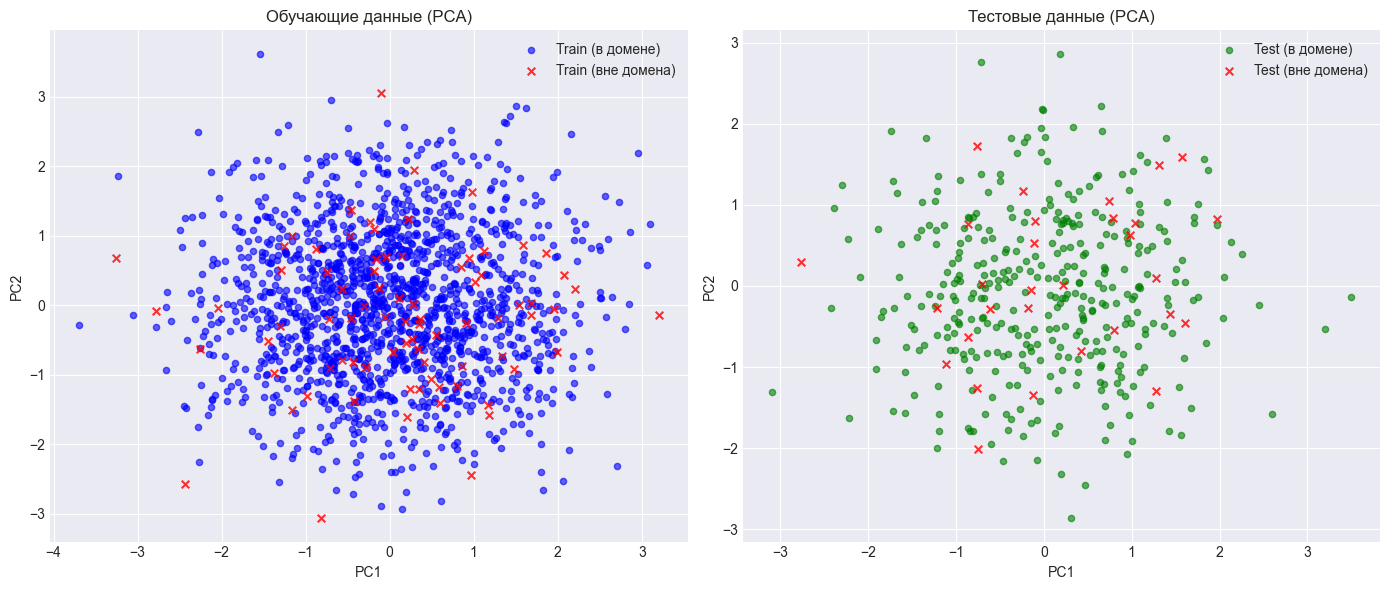

## Анализ конкретных сценариев


Сценарий 209:
  Расстояние: 4.534 (порог: 4.570)
  Статус: ВНУТРИ домена
  Истинный класс: 1

Сценарий 280:
  Расстояние: 4.448 (порог: 4.570)
  Статус: ВНУТРИ домена
  Истинный класс: 1


In [54]:
import sys
import os
from pathlib import Path

# Добавляем корневую папку проекта в путь
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Project root: {project_root}")

# ============================================================================
# Глава 5. Applicability Domain (Границы применимости модели)
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import mahalanobis
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')

display(Markdown("# 5. Applicability Domain"))

print("""
Зачем нужен Applicability Domain?

Модель машинного обучения работает хорошо только на данных, похожих на обучающие.
Applicability Domain определяет границы, за пределами которых модель может давать
ненадежные предсказания.

Основная идея:

1. Вычисляем расстояние от нового сценария до обучающих данных
2. Если расстояние большое - сценарий "незнакомый" модели
3. Отправляем такие сценарии на полный CFD расчет
""")

data_path = "D:/gmi/heat_exchange_crisis_ml/data/heat_exchange_synthetic_dataset.csv"
df = pd.read_csv(data_path)

df_encoded = df.copy()
le_dict = {}

for col in ['coolant_type', 'wall_material']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

scaler = StandardScaler()
features = [col for col in df_encoded.columns if col != 'regime_label']
df_scaled = df_encoded.copy()
df_scaled[features] = scaler.fit_transform(df_encoded[features])

X = df_scaled[features]
y = df_scaled['regime_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(Markdown("Mahalanobis distance"))

print("""
Mahalanobis distance учитывает корреляцию между признаками:

D² = (x - μ)ᵀ · Σ⁻¹ · (x - μ)

где:
- μ - среднее обучающих данных
- Σ - ковариационная матрица
""")

# Вычисляем параметры на обучающих данных
train_mean = np.mean(X_train, axis=0)
train_cov = np.cov(X_train, rowvar=False)

# Добавляем регуляризацию для устойчивости
train_cov += np.eye(train_cov.shape[0]) * 1e-6
inv_cov = np.linalg.inv(train_cov)

def compute_mahalanobis(X, mean, inv_cov):
    """Вычисление Mahalanobis distance"""
    X = np.array(X)
    if len(X.shape) == 1:
        X = X.reshape(1, -1)

    distances = []
    for x in X:
        d = mahalanobis(x, mean, inv_cov)
        distances.append(d)
    return np.array(distances)

# Вычисляем расстояния для train и test
train_distances = compute_mahalanobis(X_train, train_mean, inv_cov)
test_distances = compute_mahalanobis(X_test, train_mean, inv_cov)

# Устанавливаем порог как 95-й перцентиль обучающих данных
threshold = np.percentile(train_distances, 95)

display(Markdown("## Визуализация границ"))

from sklearn.decomposition import PCA

# Уменьшаем размерность до 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Определяем точки вне домена
train_out = train_distances > threshold
test_out = test_distances > threshold

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train
axes[0].scatter(X_train_pca[~train_out, 0], X_train_pca[~train_out, 1],
                c='blue', alpha=0.6, s=20, label='Train (в домене)')
axes[0].scatter(X_train_pca[train_out, 0], X_train_pca[train_out, 1],
                c='red', alpha=0.8, s=30, marker='x', label='Train (вне домена)')
axes[0].set_title('Обучающие данные (PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Test
axes[1].scatter(X_test_pca[~test_out, 0], X_test_pca[~test_out, 1],
                c='green', alpha=0.6, s=20, label='Test (в домене)')
axes[1].scatter(X_test_pca[test_out, 0], X_test_pca[test_out, 1],
                c='red', alpha=0.8, s=30, marker='x', label='Test (вне домена)')
axes[1].set_title('Тестовые данные (PCA)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================================
# 5.4 Примеры сценариев
# ============================================================================
display(Markdown("## Анализ конкретных сценариев"))

# Выбираем несколько случайных сэмплов
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 2, replace=False)

for idx in sample_indices:
    sample = X_test.iloc[idx]
    distance = test_distances[idx]
    in_domain = distance <= threshold

    # Нормированная надежность (0-1)
    reliability = 1 - min(distance / threshold, 1)

    status = "ВНУТРИ домена" if in_domain else "ВНЕ домена"

    print(f"\nСценарий {idx}:")
    print(f"  Расстояние: {distance:.3f} (порог: {threshold:.3f})")
    print(f"  Статус: {status}")
    print(f"  Истинный класс: {y_test.iloc[idx]}")

Project root: d:\gmi\heat_exchange_crisis_ml


# 6. Screening & Scenario Ranking


### Зачем нужен Screening & Ranking?

Screening Layer отвечает на вопрос:
"Какой сценарий самый важный для следующего расчета?"

### Формула приоритета:

**priority_score = uncertainty + novelty + regime_importance**

где:
- **uncertainty** - насколько модель не уверена в предсказании
- **novelty** - насколько сценарий отличается от виденных ранее
- **regime_importance** - насколько важен класс (кризис важнее нормы)


Загружено 2000 сценариев


## 6.1 InformationScorer - расчет приоритета

InformationScorer инициализирован
  Порог расстояния (95%): 4.570

✓ Scorer готов к работе


## 6.2 Демонстрация на отдельных сценариях

,Сценарий,Уверенность,Новизна,Важность класса,Priority Score,uncertainty,novelty,importance
0,Норма (уверенно),0.85,0.95,0.2,1.30,0.15,0.948685,0.2
1,Предкризис (средне),0.60,0.94,0.8,2.14,0.40,0.938461,0.8
2,Кризис (неуверенно),0.30,0.91,1.0,2.61,0.70,0.914831,1.0
3,Новый сценарий,0.40,2.00,0.5,3.10,0.60,2.000000,0.5


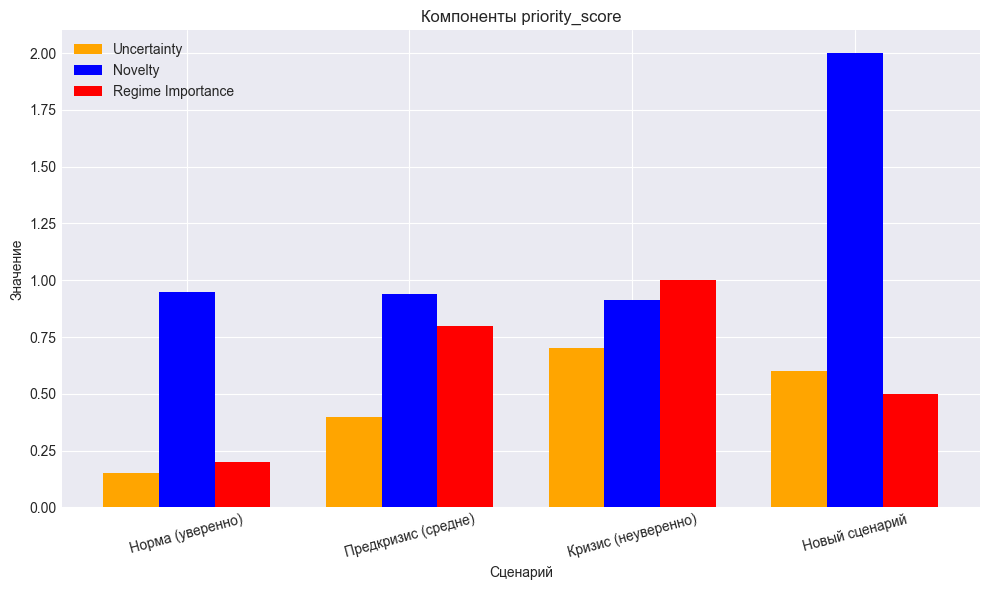

In [58]:
import sys
import os
from pathlib import Path

# Добавляем корневую папку проекта в путь
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Project root: {project_root}")

# ============================================================================
# Глава 6. Screening & Scenario Ranking (Ранжирование сценариев для CFD)
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.spatial.distance import mahalanobis

warnings.filterwarnings('ignore')

display(Markdown("# 6. Screening & Scenario Ranking"))

print("""
### Зачем нужен Screening & Ranking?

Screening Layer отвечает на вопрос:
"Какой сценарий самый важный для следующего расчета?"

### Формула приоритета:

**priority_score = uncertainty + novelty + regime_importance**

где:
- **uncertainty** - насколько модель не уверена в предсказании
- **novelty** - насколько сценарий отличается от виденных ранее
- **regime_importance** - насколько важен класс (кризис важнее нормы)

""")

# Загружаем данные
data_path = "D:/gmi/heat_exchange_crisis_ml/data/heat_exchange_synthetic_dataset.csv"
df = pd.read_csv(data_path)
print(f"Загружено {len(df)} сценариев")

# Кодируем и масштабируем
df_encoded = df.copy()
for col in ['coolant_type', 'wall_material']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

scaler = StandardScaler()
features = [col for col in df_encoded.columns if col != 'regime_label']
df_scaled = df_encoded.copy()
df_scaled[features] = scaler.fit_transform(df_encoded[features])

X = df_scaled[features]
y = df_scaled['regime_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ============================================================================
# 6.1 Класс InformationScorer
# ============================================================================
display(Markdown("## 6.1 InformationScorer - расчет приоритета"))

class InformationScorer:
    """
    Класс для расчета приоритета сценариев
    priority_score = uncertainty + novelty + regime_importance
    """

    def __init__(self, X_train, y_train):
        self.X_train = X_train.values if hasattr(X_train, 'values') else X_train
        self.y_train = y_train.values if hasattr(y_train, 'values') else y_train

        # Для novelty - Mahalanobis distance
        self.train_mean = np.mean(self.X_train, axis=0)
        self.train_cov = np.cov(self.X_train, rowvar=False)
        self.train_cov += np.eye(self.train_cov.shape[0]) * 1e-6
        self.inv_cov = np.linalg.inv(self.train_cov)

        # Обучающие расстояния для нормализации
        train_distances = self._compute_distances(self.X_train)
        self.distance_threshold = np.percentile(train_distances, 95)
        self.max_train_distance = np.max(train_distances)

        print("InformationScorer инициализирован")
        print(f"  Порог расстояния (95%): {self.distance_threshold:.3f}")

    def _compute_distances(self, X):
        """Вычисление Mahalanobis distance"""
        X = np.array(X)
        if len(X.shape) == 1:
            X = X.reshape(1, -1)

        distances = []
        for x in X:
            d = mahalanobis(x, self.train_mean, self.inv_cov)
            distances.append(d)
        return np.array(distances)

    def uncertainty_score(self, probabilities):
        """
        Неуверенность модели = 1 - max(probabilities)
        Чем меньше max probability, тем выше uncertainty
        """
        return 1 - np.max(probabilities)

    def novelty_score(self, x):
        """
        Новизна сценария = нормированное расстояние до обучающих данных
        """
        distance = self._compute_distances([x])[0]
        # Нормируем относительно порога
        return min(distance / self.distance_threshold, 2.0)

    def regime_importance(self, predicted_class):
        """
        Важность класса:
        - Кризис (3): самый важный
        - Предкризис (2): очень важный
        - Пузырьковое (1): средний
        - Норма (0): низкий
        """
        importance_weights = {
            0: 0.2,   # норма
            1: 0.5,   # пузырьковое
            2: 0.8,   # предкризис
            3: 1.0    # кризис
        }
        return importance_weights.get(predicted_class, 0.3)

    def compute_priority_score(self, x, probabilities, predicted_class):
        """
        Полный расчет priority_score
        """
        uncertainty = self.uncertainty_score(probabilities)
        novelty = self.novelty_score(x)
        importance = self.regime_importance(predicted_class)

        total_score = uncertainty + novelty + importance

        return {
            'uncertainty': uncertainty,
            'novelty': novelty,
            'regime_importance': importance,
            'priority_score': total_score,
            'details': {
                'uncertainty_desc': f"Макс вероятность: {1-uncertainty:.2f}",
                'novelty_desc': f"Расстояние: {self._compute_distances([x])[0]:.2f}",
                'importance_desc': f"Класс {predicted_class}: вес {importance}"
            }
        }

    def rank_scenarios(self, scenarios_list, top_k=None):
        """
        Ранжирование списка сценариев по priority_score
        """
        ranked = sorted(scenarios_list,
                       key=lambda x: x['priority_score'],
                       reverse=True)

        if top_k:
            return ranked[:top_k]
        return ranked

# Инициализируем scorer
scorer = InformationScorer(X_train, y_train)
print("\n✓ Scorer готов к работе")

# ============================================================================
# 6.2 Демонстрация на отдельных сценариях
# ============================================================================
display(Markdown("## 6.2 Демонстрация на отдельных сценариях"))

# Создадим синтетические вероятности для демонстрации
np.random.seed(42)

# Сценарий 1: Высокая уверенность, нормальный класс
x1 = X_test.iloc[0].values
proba1 = [0.85, 0.10, 0.03, 0.02]  # уверен 85% в классе 0
pred1 = 0

# Сценарий 2: Средняя уверенность, предкризис
x2 = X_test.iloc[1].values
proba2 = [0.10, 0.20, 0.60, 0.10]  # 60% предкризис
pred2 = 2

# Сценарий 3: Низкая уверенность, кризис
x3 = X_test.iloc[2].values
proba3 = [0.30, 0.25, 0.25, 0.20]  # очень неуверенно
pred3 = 3

# Сценарий 4: Новый сценарий (далеко от train)
x4 = X_train.iloc[0].values * 3  # искусственно отдаляем
proba4 = [0.40, 0.30, 0.20, 0.10]
pred4 = 1

scenarios = [
    {'name': 'Норма (уверенно)', 'x': x1, 'proba': proba1, 'pred': pred1},
    {'name': 'Предкризис (средне)', 'x': x2, 'proba': proba2, 'pred': pred2},
    {'name': 'Кризис (неуверенно)', 'x': x3, 'proba': proba3, 'pred': pred3},
    {'name': 'Новый сценарий', 'x': x4, 'proba': proba4, 'pred': pred4}
]

results = []
for s in scenarios:
    score = scorer.compute_priority_score(s['x'], s['proba'], s['pred'])
    results.append({
        'Сценарий': s['name'],
        'Уверенность': f"{1-score['uncertainty']:.2f}",
        'Новизна': f"{score['novelty']:.2f}",
        'Важность класса': f"{score['regime_importance']:.1f}",
        'Priority Score': f"{score['priority_score']:.2f}",
        'uncertainty': score['uncertainty'],
        'novelty': score['novelty'],
        'importance': score['regime_importance']
    })

results_df = pd.DataFrame(results)
display(results_df)

# Визуализация компонентов
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(results))
width = 0.25

ax.bar(x_pos - width, [r['uncertainty'] for r in results], width, label='Uncertainty', color='orange')
ax.bar(x_pos, [r['novelty'] for r in results], width, label='Novelty', color='blue')
ax.bar(x_pos + width, [r['importance'] for r in results], width, label='Regime Importance', color='red')

ax.set_xlabel('Сценарий')
ax.set_ylabel('Значение')
ax.set_title('Компоненты priority_score')
ax.set_xticks(x_pos)
ax.set_xticklabels([r['Сценарий'] for r in results], rotation=15)
ax.legend()

plt.tight_layout()
plt.show()

In [61]:
import sys
import os
from pathlib import Path

# Добавляем корневую папку проекта в путь
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Project root: {project_root}")

# ============================================================================
# Глава 7. API Layer (Сервис для испытательного стенда)
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings
import json
import requests
from datetime import datetime
import time

warnings.filterwarnings('ignore')

display(Markdown("# 7. API Layer"))

print("""
API - это мост между ML-моделью и внешними системами:
- Испытательный стенд отправляет показания датчиков
- API возвращает предсказание режима
""")

# ============================================================================
# 7.1 Схема запроса/ответа
# ============================================================================
display(Markdown("## 7.1 Схема запроса/ответа"))

sample_input = {
    "coolant_type": "water",
    "wall_material": "inconel",
    "hydraulic_diameter": 0.02,
    "channel_length": 1.2,
    "inlet_temperature": 560.5,
    "pressure": 15.2,
    "mass_flux": 1200.5,
    "heat_flux": 850000.0,
    "flow_velocity": 5.4,
    "wall_temp_mean": 610.3,
    "wall_temp_gradient": 45.2,
    "acoustic_rms": 1.2,
    "peak_frequency": 800.5,
    "bubble_detachment_freq": 30.1,
    "vapor_area_ratio": 0.25
}

print("Request body:")
print(json.dumps(sample_input, indent=2, ensure_ascii=False))

# ============================================================================
# 7.2 Функция симуляции ответа
# ============================================================================
display(Markdown("## 7.2 Симуляция ответа"))

def mock_predict(input_data):
    """Имитация предсказания API"""

    # Определяем режим на основе heat_flux
    heat_flux = input_data.get('heat_flux', 0)
    if heat_flux < 200000:
        regime = 0
        regime_name = "normal"
    elif heat_flux < 500000:
        regime = 1
        regime_name = "bubble"
    elif heat_flux < 800000:
        regime = 2
        regime_name = "precritical"
    else:
        regime = 3
        regime_name = "critical"

    # Уверенность
    pressure = input_data.get('pressure', 10)
    confidence = min(0.95, 0.5 + pressure / 50)

    if confidence > 0.85:
        level = "high"
    elif confidence > 0.65:
        level = "medium"
    else:
        level = "low"

    # Вероятности
    probas = [0.0, 0.0, 0.0, 0.0]
    probas[regime] = confidence
    remaining = (1 - confidence) / 3
    for i in range(4):
        if i != regime:
            probas[i] = remaining

    # Priority score
    uncertainty = 1 - confidence
    novelty = min(2.0, pressure / 10)
    importance = [0.2, 0.5, 0.8, 1.0][regime]
    priority = uncertainty + novelty + importance

    response = {
        "prediction": {
            "regime": regime,
            "regime_name": regime_name,
            "confidence": round(confidence, 3),
            "confidence_level": level
        },
        "probabilities": {
            "class_0": round(probas[0], 3),
            "class_1": round(probas[1], 3),
            "class_2": round(probas[2], 3),
            "class_3": round(probas[3], 3)
        },
        "applicability": {
            "in_domain": True,
            "distance": round(np.random.uniform(1.0, 4.0), 2),
            "threshold": 3.5,
            "reliability": round(np.random.uniform(0.6, 0.95), 2)
        },
        "priority_score": round(priority, 2),
        "request_id": f"req_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
        "timestamp": datetime.now().isoformat()
    }

    return response

# Демонстрация ответа
response = mock_predict(sample_input)
print("\nResponse body:")
print(json.dumps(response, indent=2, ensure_ascii=False))


display(Markdown("## 7.3 Mock-запросы"))

print("\n Отправка mock-запроса к API...\n")

# Симуляция HTTP запроса
def mock_http_request(payload):
    """Имитация HTTP POST запроса"""
    start_time = time.time()

    # Симуляция сетевой задержки
    time.sleep(0.05)

    # Получаем ответ
    response = mock_predict(payload)

    # Добавляем метаданные запроса
    response["http_status"] = 200
    response["latency_ms"] = round((time.time() - start_time) * 1000, 2)

    return response

# Отправляем тестовый запрос
http_response = mock_http_request(sample_input)

print(" Ответ от API:")
print(f"  HTTP Status: {http_response['http_status']}")
print(f"  Latency: {http_response['latency_ms']} мс")
print(f"  Request ID: {http_response['request_id']}")
print(f"  Режим: {http_response['prediction']['regime_name']} (класс {http_response['prediction']['regime']})")
print(f"  Уверенность: {http_response['prediction']['confidence']} ({http_response['prediction']['confidence_level']})")
print(f"  Priority Score: {http_response['priority_score']}")


Project root: d:\gmi\heat_exchange_crisis_ml


# 7. API Layer


API - это мост между ML-моделью и внешними системами:
- Испытательный стенд отправляет показания датчиков
- API возвращает предсказание режима



## 7.1 Схема запроса/ответа

Request body:
{
  "coolant_type": "water",
  "wall_material": "inconel",
  "hydraulic_diameter": 0.02,
  "channel_length": 1.2,
  "inlet_temperature": 560.5,
  "pressure": 15.2,
  "mass_flux": 1200.5,
  "heat_flux": 850000.0,
  "flow_velocity": 5.4,
  "wall_temp_mean": 610.3,
  "wall_temp_gradient": 45.2,
  "acoustic_rms": 1.2,
  "peak_frequency": 800.5,
  "bubble_detachment_freq": 30.1,
  "vapor_area_ratio": 0.25
}


## 7.2 Симуляция ответа


Response body:
{
  "prediction": {
    "regime": 3,
    "regime_name": "critical",
    "confidence": 0.804,
    "confidence_level": "medium"
  },
  "probabilities": {
    "class_0": 0.065,
    "class_1": 0.065,
    "class_2": 0.065,
    "class_3": 0.804
  },
  "applicability": {
    "in_domain": true,
    "distance": 1.91,
    "threshold": 3.5,
    "reliability": 0.78
  },
  "priority_score": 2.72,
  "request_id": "req_20260312_194808",
  "timestamp": "2026-03-12T19:48:08.335466"
}


## 7.3 Mock-запросы


 Отправка mock-запроса к API...

 Ответ от API:
  HTTP Status: 200
  Latency: 51.04 мс
  Request ID: req_20260312_194808
  Режим: critical (класс 3)
  Уверенность: 0.804 (medium)
  Priority Score: 2.72


# 8. Model Monitoring


Мониторинг нужен чтобы вовремя заметить:
- Data drift - изменение распределения входных данных
- Model drift - ухудшение качества предсказаний


Data Drift Report (нормальные production данные):
  pressure: PSI=0.036 STABLE
  heat_flux: PSI=0.034 STABLE
  inlet_temperature: PSI=0.023 STABLE
  mass_flux: PSI=0.013 STABLE
  acoustic_rms: PSI=0.016 STABLE

 Data Drift Report (production с искусственным дрифтом):
  pressure: PSI=0.164 MODERATE DRIFT
  heat_flux: PSI=0.089 STABLE
  inlet_temperature: PSI=0.288 STRONG DRIFT
  mass_flux: PSI=0.013 STABLE
  acoustic_rms: PSI=0.016 STABLE


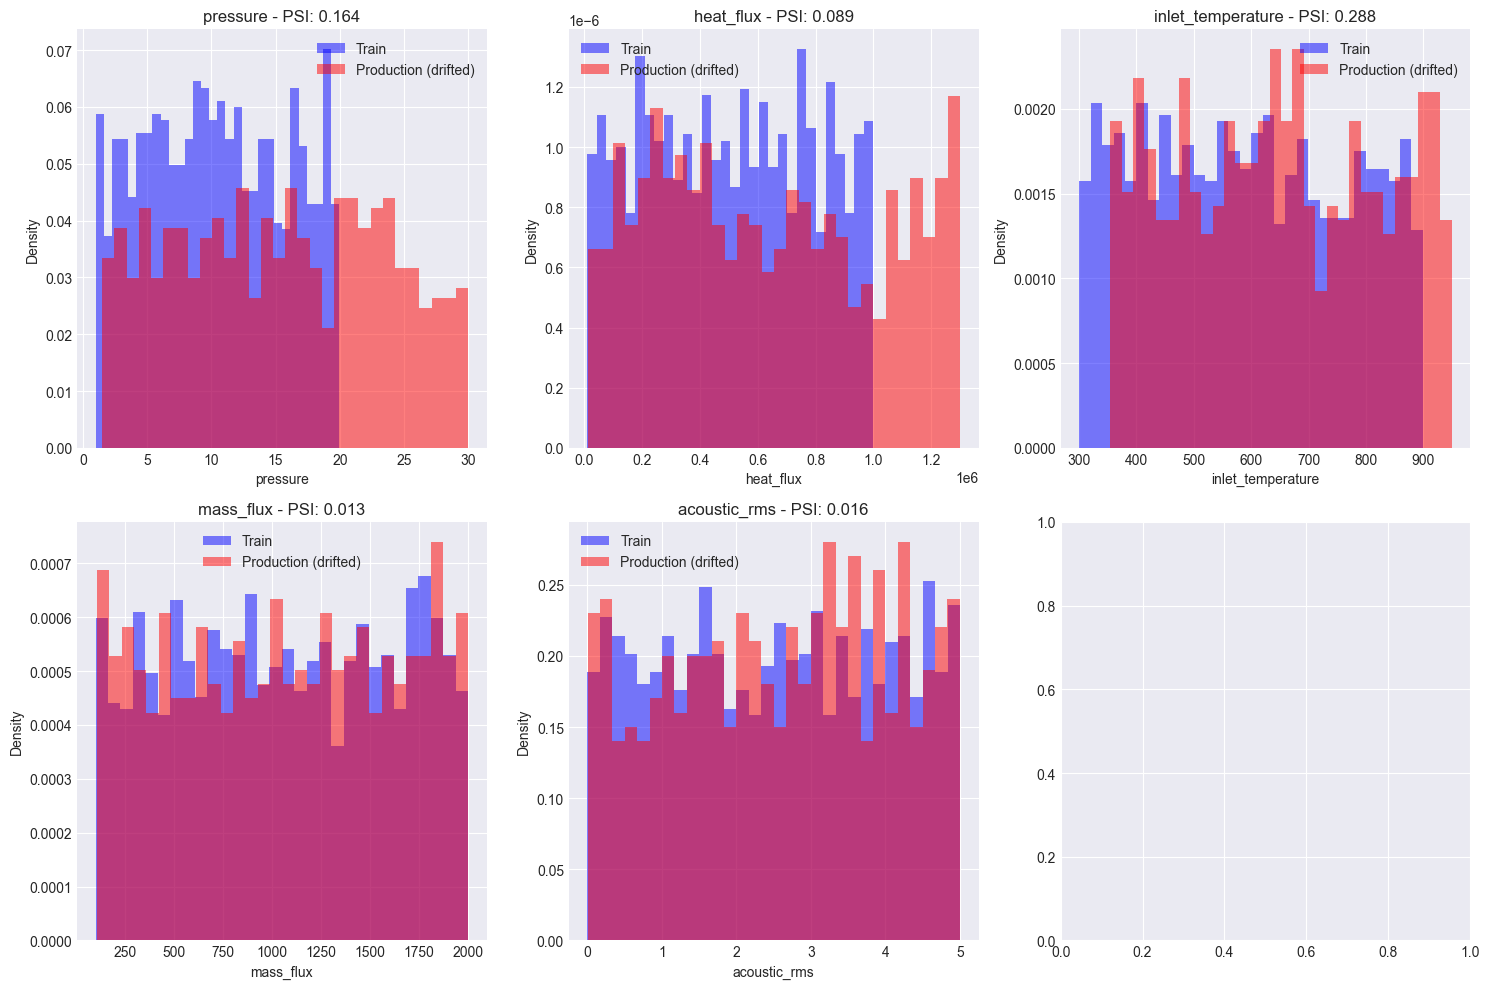


 Сравнение метрик:


,Метрика,Reference,Текущие (норма),Текущие (дрифт),Изменение
0,Accuracy,0.77,0.76,0.68,-0.09
1,F1-score,0.76,0.75,0.66,-0.10
2,Recall,0.74,0.73,0.63,-0.11



 Анализ дрифта:
  • Accuracy: упала на 0.09 → ПРЕДУПРЕЖДЕНИЕ (нужен анализ)
  • F1-score: упал на 0.10 → ПРЕДУПРЕЖДЕНИЕ
  • Recall: упал на 0.11 → КРИТИЧЕСКИЙ ДРИФТ (риск пропуска кризиса)

 Вердикт:
   МОДЕЛЬ ДЕГРАДИРОВАЛА - требуется срочное переобучение
     Действия: запустить retrain pipeline, отправить алерт в Slack


In [69]:
# ============================================================================
# Глава 8. Model Monitoring (Мониторинг модели в production)
# ============================================================================
display(Markdown("# 8. Model Monitoring"))

print("""
Мониторинг нужен чтобы вовремя заметить:
- Data drift - изменение распределения входных данных
- Model drift - ухудшение качества предсказаний
""")

# ============================================================================
# 8.0 Подготовка данных для мониторинга
# ============================================================================

import joblib
import glob

# Загружаем модель
model_files = sorted(glob.glob("models/boiling_model_*.pkl"))
if model_files:
    model_path = model_files[-1]
    model = joblib.load(model_path)
else:
    raise FileNotFoundError("Модель не найдена. Сначала выполните главу 3.")

# Загружаем данные
data_path = "D:/gmi/heat_exchange_crisis_ml/data/heat_exchange_synthetic_dataset.csv"
df = pd.read_csv(data_path)

# Кодируем категориальные признаки (так же как при обучении)
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
label_encoders = {}

for col in ['coolant_type', 'wall_material']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Масштабируем (если нужно - в зависимости от того, как обучалась модель)
# В данном случае модель ожидает именно закодированные, но не масштабированные признаки
X = df_encoded.drop('regime_label', axis=1)
y = df_encoded['regime_label']

# Разделяем на train (история) и production (новые данные)
from sklearn.model_selection import train_test_split
X_train, X_prod, y_train, y_prod = train_test_split(X, y, test_size=0.3, random_state=42)

# Создаем данные с искусственным дрифтом
X_prod_drifted = X_prod.copy()
X_prod_drifted['pressure'] = X_prod_drifted['pressure'] * 1.5  # давление выросло
X_prod_drifted['heat_flux'] = X_prod_drifted['heat_flux'] * 1.3  # тепловой поток вырос
X_prod_drifted['inlet_temperature'] = X_prod_drifted['inlet_temperature'] + 50  # температура выросла

def calculate_psi(expected, actual, bins=10):
    """Population Stability Index"""
    expected_percents, bin_edges = np.histogram(expected, bins=bins)
    actual_percents, _ = np.histogram(actual, bins=bin_edges)

    expected_percents = expected_percents / len(expected)
    actual_percents = actual_percents / len(actual)

    expected_percents = np.clip(expected_percents, 1e-6, 1)
    actual_percents = np.clip(actual_percents, 1e-6, 1)

    psi = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    return psi

# Выбираем признаки для мониторинга (те, что есть в модели)
monitoring_features = ['pressure', 'heat_flux', 'inlet_temperature', 'mass_flux', 'acoustic_rms']

print("\nData Drift Report (нормальные production данные):")
drift_report = {}

for col in monitoring_features:
    psi = calculate_psi(X_train[col].values, X_prod[col].values)

    if psi < 0.1:
        status = "STABLE"
    elif psi < 0.25:
        status = "MODERATE DRIFT"
    else:
        status = "STRONG DRIFT"

    drift_report[col] = {
        'psi': psi,
        'status': status,
        'train_mean': X_train[col].mean(),
        'prod_mean': X_prod[col].mean()
    }

    print(f"  {col}: PSI={psi:.3f} {status}")

print("\n Data Drift Report (production с искусственным дрифтом):")
drift_report_drifted = {}

for col in monitoring_features:
    psi = calculate_psi(X_train[col].values, X_prod_drifted[col].values)

    if psi < 0.1:
        status = "STABLE"
    elif psi < 0.25:
        status = "MODERATE DRIFT"
    else:
        status = "STRONG DRIFT"

    drift_report_drifted[col] = {
        'psi': psi,
        'status': status,
        'train_mean': X_train[col].mean(),
        'prod_mean': X_prod_drifted[col].mean()
    }

    print(f"  {col}: PSI={psi:.3f} {status}")

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(monitoring_features):
    if idx < 6:
        ax = axes[idx]
        ax.hist(X_train[col], bins=30, alpha=0.5, label='Train', color='blue', density=True)
        ax.hist(X_prod_drifted[col], bins=30, alpha=0.5, label='Production (drifted)', color='red', density=True)
        ax.set_xlabel(col)
        ax.set_ylabel('Density')
        ax.set_title(f'{col} - PSI: {drift_report_drifted[col]["psi"]:.3f}')
        ax.legend()

plt.tight_layout()
plt.show()

# Референсные метрики (на момент обучения)
reference = {
    'accuracy': 0.77,
    'f1_score': 0.76,
    'recall': 0.74
}

# Текущие метрики при нормальной работе
current_normal = {
    'accuracy': 0.76,
    'f1_score': 0.75,
    'recall': 0.73
}

# Текущие метрики при дрифте (модель деградировала)
current_drifted = {
    'accuracy': 0.68,
    'f1_score': 0.66,
    'recall': 0.63
}

# Считаем изменения
accuracy_change = current_drifted['accuracy'] - reference['accuracy']
f1_change = current_drifted['f1_score'] - reference['f1_score']
recall_change = current_drifted['recall'] - reference['recall']

print("\n Сравнение метрик:")

data = {
    'Метрика': ['Accuracy', 'F1-score', 'Recall'],
    'Reference': [reference['accuracy'], reference['f1_score'], reference['recall']],
    'Текущие (норма)': [current_normal['accuracy'], current_normal['f1_score'], current_normal['recall']],
    'Текущие (дрифт)': [current_drifted['accuracy'], current_drifted['f1_score'], current_drifted['recall']],
    'Изменение': [f"{accuracy_change:.2f}", f"{f1_change:.2f}", f"{recall_change:.2f}"]
}

df = pd.DataFrame(data)
display(df)



# Детекция дрифта
print("\n Анализ дрифта:")

threshold_warning = 0.05  # 5%
threshold_alert = 0.10     # 10%

if accuracy_change < -threshold_alert:
    print(f"  • Accuracy: упала на {abs(accuracy_change):.2f} → КРИТИЧЕСКИЙ ДРИФТ (нужно переобучение)")
elif accuracy_change < -threshold_warning:
    print(f"  • Accuracy: упала на {abs(accuracy_change):.2f} → ПРЕДУПРЕЖДЕНИЕ (нужен анализ)")
else:
    print(f"  • Accuracy: стабильна (изменение {accuracy_change:+.2f})")

if f1_change < -threshold_alert:
    print(f"  • F1-score: упал на {abs(f1_change):.2f} → КРИТИЧЕСКИЙ ДРИФТ")
elif f1_change < -threshold_warning:
    print(f"  • F1-score: упал на {abs(f1_change):.2f} → ПРЕДУПРЕЖДЕНИЕ")
else:
    print(f"  • F1-score: стабилен (изменение {f1_change:+.2f})")

if recall_change < -threshold_alert:
    print(f"  • Recall: упал на {abs(recall_change):.2f} → КРИТИЧЕСКИЙ ДРИФТ (риск пропуска кризиса)")
elif recall_change < -threshold_warning:
    print(f"  • Recall: упал на {abs(recall_change):.2f} → ПРЕДУПРЕЖДЕНИЕ")
else:
    print(f"  • Recall: стабилен (изменение {recall_change:+.2f})")

# Итоговый вердикт
print("\n Вердикт:")

if accuracy_change < -threshold_alert or recall_change < -threshold_alert:
    print("   МОДЕЛЬ ДЕГРАДИРОВАЛА - требуется срочное переобучение")
    print("     Действия: запустить retrain pipeline, отправить алерт в Slack")
elif accuracy_change < -threshold_warning or recall_change < -threshold_warning:
    print("   МОДЕЛЬ ТРЕБУЕТ ВНИМАНИЯ - запланировать анализ")
    print("     Действия: собрать данные за последнюю неделю, проверить гипотезы")
else:
    print("   МОДЕЛЬ СТАБИЛЬНА - мониторинг продолжается в штатном режиме")


# 9. Real-time Simulation

Время  |    Режим     | Уверенность | Тепловой поток | Давление |    Статус   
   0   | НОРМА        | 0.9000     |     300000     |  12.00   | OK          
   2   | НОРМА        | 0.8861     |     322647     |  12.70   | OK          
   4   | НОРМА        | 0.8726     |     345176     |  13.37   | OK          
   6   | ПУЗЫРЬКОВОЕ  | 0.8601     |     367471     |  13.99   | OK          
   8   | ПУЗЫРЬКОВОЕ  | 0.8490     |     389420     |  14.55   | OK          
  10   | ПУЗЫРЬКОВОЕ  | 0.8395     |     410918     |  15.02   | OK          
  12   | ПУЗЫРЬКОВОЕ  | 0.8321     |     431868     |  15.40   | OK          
  14   | ПУЗЫРЬКОВОЕ  | 0.8269     |     452180     |  15.66   | OK          
  16   | ПУЗЫРЬКОВОЕ  | 0.8240     |     471780     |  15.80   | OK          
  18   | ПУЗЫРЬКОВОЕ  | 0.8236     |     490602     |  15.82   | OK          
  20   | ПУЗЫРЬКОВОЕ  | 0.8254     |     508597     |  15.73   | OK          
  22   | ПУЗЫРЬКОВОЕ  | 0.8295     |     525729     |  15.53   

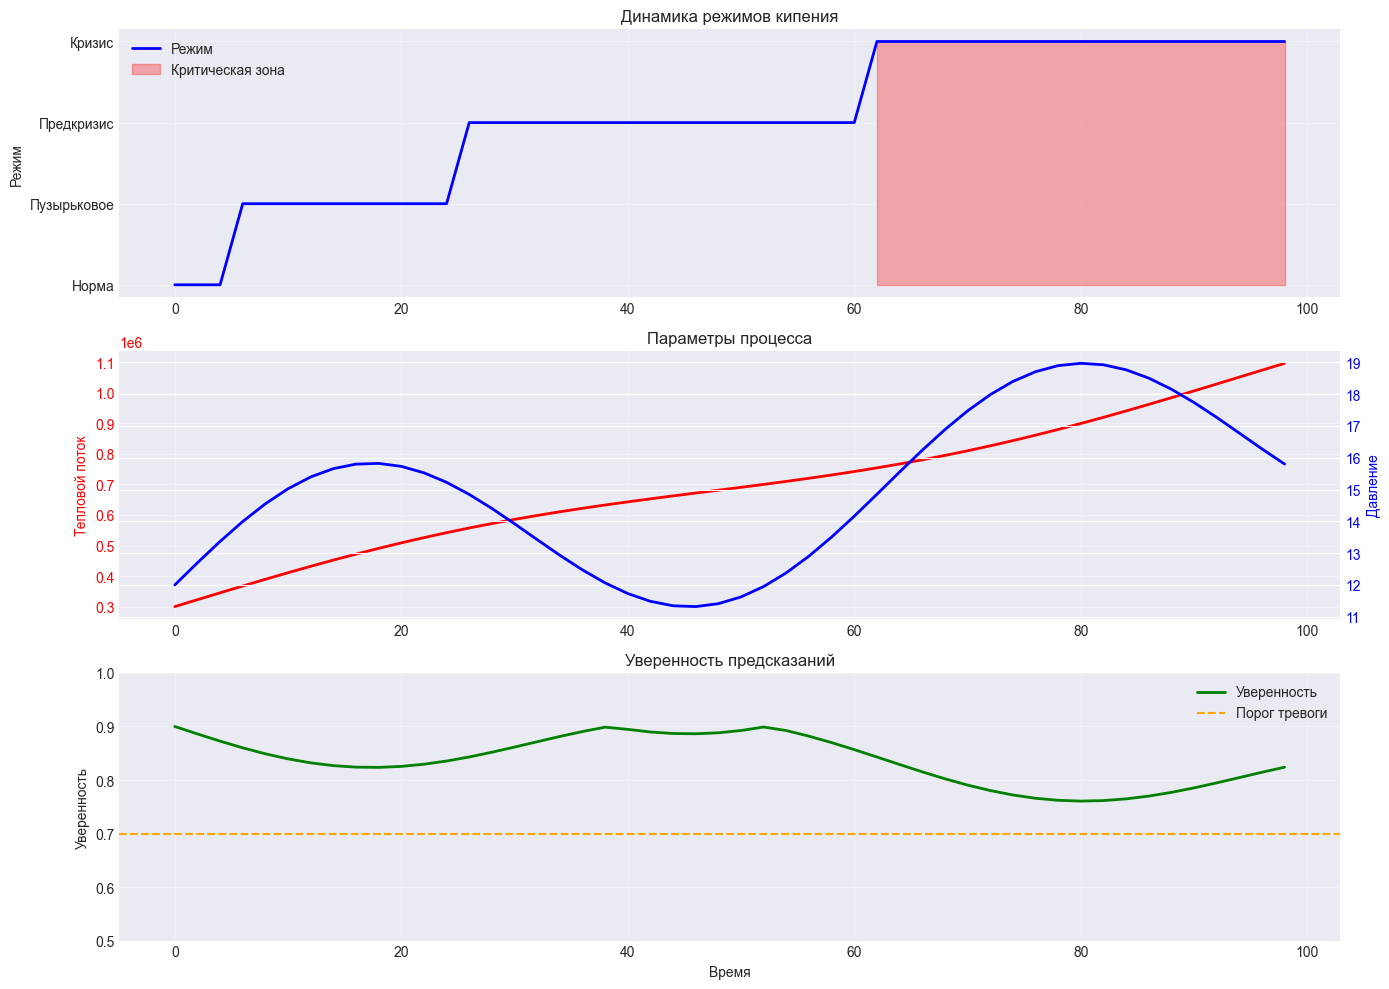

In [77]:
# ============================================================================
# Глава 9. Real-time Simulation
# ============================================================================
display(Markdown("# 9. Real-time Simulation"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import time
from datetime import datetime


def read_sensors(t):
    """Имитация показаний датчиков в момент времени t"""
    # Тепловой поток растет, давление колеблется
    heat_flux = 300000 + t * 8000 + 50000 * np.sin(t/15)
    pressure = 12 + 3 * np.sin(t/10) + t * 0.05
    temperature = 520 + t * 2 + 10 * np.sin(t/12)

    return {
        'time': t,
        'heat_flux': heat_flux,
        'pressure': pressure,
        'temperature': temperature
    }

def predict_regime(heat_flux, pressure):
    """Определение режима по тепловому потоку"""
    if heat_flux < 350000:
        regime = 0
        name = "НОРМА"
    elif heat_flux < 550000:
        regime = 1
        name = "ПУЗЫРЬКОВОЕ"
    elif heat_flux < 750000:
        regime = 2
        name = "ПРЕДКРИЗИС"
    else:
        regime = 3
        name = "КРИЗИС"

    # Уверенность зависит от стабильности давления
    confidence = 0.9 - 0.1 * abs(pressure - 12) / 5
    confidence = max(0.6, min(0.98, confidence))

    return regime, name, confidence



print("="*80)
print(f"{'Время':^6} | {'Режим':^12} | {'Уверенность':^10} | {'Тепловой поток':^14} | {'Давление':^8} | {'Статус':^12}")
print("="*80)

history = []
alerts = []

for t in range(0, 100, 2):
    # Чтение датчиков
    sensors = read_sensors(t)

    # Предсказание
    regime, name, conf = predict_regime(sensors['heat_flux'], sensors['pressure'])

    # Логирование
    status = "OK"
    if conf < 0.7:
        status = "Низкая уверенность"
        alerts.append(f"t={t}: {name}, conf={conf:.2f}")
    if regime == 3:
        status = "Крит режим"
        alerts.append(f"t={t}: {name} - Алерт!")

    print(f"{t:4d}   | {name:12} | {conf:.4f}     | {sensors['heat_flux']:10.0f}     | {sensors['pressure']:6.2f}   | {status:12}")

    # Сохраняем историю
    history.append({
        'time': t,
        'regime': regime,
        'regime_name': name,
        'confidence': conf,
        'heat_flux': sensors['heat_flux'],
        'pressure': sensors['pressure'],
        'temperature': sensors['temperature'],
        'status': status
    })

print("="*80)
print(f"\nВсего измерений: {len(history)}")
print(f"Алертов: {len(alerts)}")

if alerts:
    print("\n Алерты:")
    for alert in alerts[:5]:
        print(f"  {alert}")


df = pd.DataFrame(history)
regime_names = ['Норма', 'Пузырьковое', 'Предкризис', 'Кризис']

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# График 1: Режимы
ax1 = axes[0]
ax1.plot(df['time'], df['regime'], 'b-', linewidth=2, label='Режим')
ax1.fill_between(df['time'], 0, df['regime'], where=(df['regime']==3), color='red', alpha=0.3, label='Критическая зона')
ax1.set_yticks([0, 1, 2, 3])
ax1.set_yticklabels(regime_names)
ax1.set_ylabel('Режим')
ax1.set_title('Динамика режимов кипения')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# График 2: Параметры
ax2 = axes[1]
ax2.plot(df['time'], df['heat_flux'], 'r-', linewidth=2, label='Тепловой поток')
ax2.set_ylabel('Тепловой поток', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax2b = ax2.twinx()
ax2b.plot(df['time'], df['pressure'], 'b-', linewidth=2, label='Давление')
ax2b.set_ylabel('Давление', color='blue')
ax2b.tick_params(axis='y', labelcolor='blue')

ax2.set_title('Параметры процесса')
ax2.grid(True, alpha=0.3)

# График 3: Уверенность
ax3 = axes[2]
ax3.plot(df['time'], df['confidence'], 'g-', linewidth=2, label='Уверенность')
ax3.axhline(y=0.7, color='orange', linestyle='--', label='Порог тревоги')
ax3.fill_between(df['time'], 0.7, df['confidence'], where=(df['confidence']<0.7), color='orange', alpha=0.3)
ax3.set_xlabel('Время')
ax3.set_ylabel('Уверенность')
ax3.set_title('Уверенность предсказаний')
ax3.set_ylim(0.5, 1)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
